In [28]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score

In [3]:
path = 'C:/Users/brake/OneDrive/Documenten/GitHub/Thesis/MSc-Thesis-Brent/US-Air_Baseline/data/raw_usair_data'
files = os.listdir(path)
dfs = []

for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(path, file)
        df = pd.read_csv(file_path)
        dfs.append(df)
        
all_us_data = pd.concat(dfs, ignore_index=True)

In [4]:
all_us_data = all_us_data[all_us_data['ORIGIN'] != all_us_data['DEST']]
all_us_data

,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,SEATS,PASSENGERS,DISTANCE,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,YEAR,MONTH,Unnamed: 17
0,0.0,1.0,150.0,119.0,987.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,12266,IAH,"Houston, TX",TX,2021,3,NaN
1,0.0,6.0,900.0,191.0,325.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,11540,ELP,"El Paso, TX",TX,2021,3,NaN
2,0.0,1.0,150.0,62.0,995.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,10747,BRO,"Brownsville, TX",TX,2021,3,NaN
3,0.0,1.0,150.0,17.0,828.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,13061,LRD,"Laredo, TX",TX,2021,3,NaN
4,0.0,3.0,450.0,34.0,595.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,11292,DEN,"Denver, CO",CO,2021,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6376427,868.0,857.0,7713.0,5895.0,91.0,9K,Cape Air,10154,ACK,"Nantucket, MA",MA,10721,BOS,"Boston, MA",MA,2010,8,NaN
6376428,884.0,882.0,107526.0,84717.0,100.0,HA,Hawaiian Airlines Inc.,13830,OGG,"Kahului, HI",HI,12173,HNL,"Honolulu, HI",HI,2010,8,NaN
6376429,885.0,874.0,7866.0,4979.0,91.0,9K,Cape Air,10154,ACK,"Nantucket, MA",MA,10721,BOS,"Boston, MA",MA,2010,7,NaN
6376430,889.0,888.0,108279.0,86174.0,100.0,HA,Hawaiian Airlines Inc.,13830,OGG,"Kahului, HI",HI,12173,HNL,"Honolulu, HI",HI,2010,7,NaN


In [5]:
# Calculate the lower bound for outliers using the IQR method
q1 = all_us_data['DEPARTURES_PERFORMED'].quantile(0.25)
q3 = all_us_data['DEPARTURES_PERFORMED'].quantile(0.75)
iqr = q3 - q1
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
lower_bound = q1 - 1.5 * iqr

# Remove rows with DEPARTURES_PERFORMED below the lower bound
us_df = all_us_data[all_us_data['DEPARTURES_PERFORMED'] >= lower_bound]
us_df.reset_index(drop=True, inplace=True)

Q1: 1.0, Q3: 31.0, IQR: 30.0


In [7]:
# Define a threshold for "significantly less", e.g., 20% less than scheduled
threshold = 0.8
us_df['SIGNIFICANTLY_LESS'] = us_df['DEPARTURES_PERFORMED'] < (threshold * us_df['DEPARTURES_SCHEDULED'])
print(us_df[us_df['SIGNIFICANTLY_LESS'] == True].shape[0] / len(us_df))

0.02279176944732245


In [8]:
import networkx as nx

# Get unique dates and stations
us_df['Date'] = pd.to_datetime(us_df[['YEAR', 'MONTH']].assign(DAY=1))
unique_dates = us_df['Date'].dt.date.unique()
sources = us_df['ORIGIN'].unique()
destinations = us_df['DEST'].unique()
stations = list(set(sources).union(set(destinations)))
print(len(stations))
print(len(unique_dates))
# Calculate the top 10% most popular stations by total departures (origin + dest)
station_counts = pd.concat([
    us_df['ORIGIN'], 
    us_df['DEST']
]).value_counts()

top_10pct_count = int(len(station_counts) * 0.10)
top_stations = station_counts.nlargest(top_10pct_count).index

# Filter dataset to only include flights between top stations
filtered_us_df = us_df[
    us_df['ORIGIN'].isin(top_stations) & us_df['DEST'].isin(top_stations)
].reset_index(drop=True)

print(f"Filtered dataset shape: {filtered_us_df.shape}")
filtered_us_df.head()

2310
212
Filtered dataset shape: (4933438, 20)


,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,SEATS,PASSENGERS,DISTANCE,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,YEAR,MONTH,Unnamed: 17,SIGNIFICANTLY_LESS,Date
0,0.0,1.0,150.0,119.0,987.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,12266,IAH,"Houston, TX",TX,2021,3,NaN,False,2021-03-01
1,0.0,6.0,900.0,191.0,325.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,11540,ELP,"El Paso, TX",TX,2021,3,NaN,False,2021-03-01
2,0.0,1.0,150.0,17.0,828.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,13061,LRD,"Laredo, TX",TX,2021,3,NaN,False,2021-03-01
3,0.0,3.0,450.0,34.0,595.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,11292,DEN,"Denver, CO",CO,2021,3,NaN,False,2021-03-01
4,0.0,2.0,300.0,17.0,276.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",10466,AZA,"Phoenix, AZ",AZ,12889,LAS,"Las Vegas, NV",NV,2021,3,NaN,False,2021-03-01


In [10]:
summer_us_df = filtered_us_df[filtered_us_df['MONTH'].isin([6, 7, 8])].reset_index(drop=True)
print(summer_us_df[summer_us_df['SIGNIFICANTLY_LESS'] == True].shape[0] / len(summer_us_df))
summer_us_df

0.01958393677979976


,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,SEATS,PASSENGERS,DISTANCE,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,YEAR,MONTH,Unnamed: 17,SIGNIFICANTLY_LESS,Date
0,0.0,3.0,12.0,5.0,143.0,8V,Wright Air Service,11630,FAI,"Fairbanks, AK",AK,11833,FYU,"Fort Yukon, AK",AK,2021,6,NaN,False,2021-06-01
1,0.0,3.0,12.0,0.0,143.0,8V,Wright Air Service,11833,FYU,"Fort Yukon, AK",AK,11630,FAI,"Fairbanks, AK",AK,2021,6,NaN,False,2021-06-01
2,0.0,1.0,7.0,0.0,269.0,8V,Wright Air Service,13196,MCG,"McGrath, AK",AK,11630,FAI,"Fairbanks, AK",AK,2021,6,NaN,False,2021-06-01
3,0.0,1.0,7.0,2.0,269.0,8V,Wright Air Service,11630,FAI,"Fairbanks, AK",AK,13196,MCG,"McGrath, AK",AK,2021,6,NaN,False,2021-06-01
4,0.0,1.0,7.0,7.0,268.0,8V,Wright Air Service,11630,FAI,"Fairbanks, AK",AK,11844,GAL,"Galena, AK",AK,2021,6,NaN,False,2021-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270475,868.0,857.0,7713.0,5895.0,91.0,9K,Cape Air,10154,ACK,"Nantucket, MA",MA,10721,BOS,"Boston, MA",MA,2010,8,NaN,False,2010-08-01
1270476,884.0,882.0,107526.0,84717.0,100.0,HA,Hawaiian Airlines Inc.,13830,OGG,"Kahului, HI",HI,12173,HNL,"Honolulu, HI",HI,2010,8,NaN,False,2010-08-01
1270477,885.0,874.0,7866.0,4979.0,91.0,9K,Cape Air,10154,ACK,"Nantucket, MA",MA,10721,BOS,"Boston, MA",MA,2010,7,NaN,False,2010-07-01
1270478,889.0,888.0,108279.0,86174.0,100.0,HA,Hawaiian Airlines Inc.,13830,OGG,"Kahului, HI",HI,12173,HNL,"Honolulu, HI",HI,2010,7,NaN,False,2010-07-01


In [11]:
import networkx as nx

# Get unique dates and stations
summer_us_df['Date'] = pd.to_datetime(summer_us_df[['YEAR', 'MONTH']].assign(DAY=1))
unique_dates = summer_us_df['Date'].dt.date.unique()
sources = summer_us_df['ORIGIN'].unique()
destinations = summer_us_df['DEST'].unique()
stations = list(set(sources).union(set(destinations)))

# Function to create daily graph and calculate node features
def create_monthly_graph(date, df):
    # Filter data for the specific date
    daily_df = df[df['Date'].dt.date == date]
    
    # Create graph
    G = nx.DiGraph()
    G.add_nodes_from(stations)
    
    # Add weighted edges
    for _, row in daily_df.iterrows():
        G.add_edge(
            row['ORIGIN'], 
            row['DEST'], 
            weight=row['DEPARTURES_PERFORMED'], 
            distance=row['DISTANCE']
        )
        # print(f"Added edge from {row['source']} to {row['target']} with weight {row['Rides planned']} and distance {row['distance']}")
    
    # Calculate node features
    node_features = {}
    for node in G.nodes():
        # Degree (number of connections)
        degree = G.degree(node)
        
        # Weighted degree (sum of rides planned)
        weighted_degree = sum(
            G[node][neighbor]['weight'] 
            for neighbor in G.neighbors(node)
        )
        
        # Average distance to neighbors
        avg_distance = (
            sum(G[node][neighbor]['distance'] for neighbor in G.neighbors(node)) / degree
            if degree > 0 else 0
        )
        
        node_features[node] = {
            'degree': degree,
            'weighted_degree': weighted_degree,
            'avg_distance': avg_distance
        }
    # Calculate edge features
    edge_features = {}
    for edge in G.edges():
        source, target = edge
        
        # Convert directed graph to undirected graph for compatibility with certain metrics
        G_undirected = G.to_undirected()
        
        # Number of common neighbors
        common_neighbors = len(list(nx.common_neighbors(G_undirected, source, target)))
        
        # Jaccard coefficient (ratio of common neighbors to total unique neighbors)
        jaccard = list(nx.jaccard_coefficient(G_undirected, [(source, target)]))[0][2]
        
        # Preferential attachment (product of degrees)
        pref_attachment = G.degree(source) * G.degree(target)
        
        # Adamic-Adar index (weighted common neighbors by inverse log of degree)
        adamic_adar = list(nx.adamic_adar_index(G_undirected, [(source, target)]))[0][2]
        
        # Resource allocation index (similar to Adamic-Adar but simpler weighting)
        resource_allocation = list(nx.resource_allocation_index(G_undirected, [(source, target)]))[0][2]
        
        # Edge weight (rides planned)
        weight = G[source][target]['weight']
        
        # Edge distance
        distance = G[source][target]['distance']
        
        edge_features[edge] = {
            'common_neighbors': common_neighbors,
            'jaccard_coefficient': jaccard,
            'preferential_attachment': pref_attachment,
            'adamic_adar_index': adamic_adar,
            'resource_allocation_index': resource_allocation,
            'weight': weight,
            'distance': distance
        }
    
    return G, node_features, edge_features

example_date = unique_dates[0]
G, node_features, edge_features = create_monthly_graph(example_date, summer_us_df)
daily_df = summer_us_df[summer_us_df['Date'].dt.date == example_date]

In [14]:
summer_us_df.set_index('Date', inplace=True)
summer_us_df.sort_index(inplace=True)

In [15]:
summer_us_df

,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,SEATS,PASSENGERS,DISTANCE,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,YEAR,MONTH,Unnamed: 17,SIGNIFICANTLY_LESS
Date,,,,,,,,,,,,,,,,,,,
2004-06-01,106.0,106.0,14522.0,11149.0,159.0,WN,Southwest Airlines Co.,10821,BWI,"Baltimore, MD",MD,13931,ORF,"Norfolk, VA",VA,2004,6,NaN,False
2004-06-01,56.0,56.0,2800.0,1858.0,407.0,RP,Chautauqua Airlines Inc.,13296,MHT,"Manchester, NH",NH,11278,DCA,"Washington, DC",VA,2004,6,NaN,False
2004-06-01,56.0,55.0,2750.0,2344.0,843.0,DH,Independence Air,13930,ORD,"Chicago, IL",IL,13296,MHT,"Manchester, NH",NH,2004,6,NaN,False
2004-06-01,56.0,51.0,6152.0,5043.0,843.0,UA,United Air Lines Inc.,13930,ORD,"Chicago, IL",IL,13296,MHT,"Manchester, NH",NH,2004,6,NaN,False
2004-06-01,56.0,55.0,1760.0,1151.0,475.0,AL,Skyway Airlines,13342,MKE,"Milwaukee, WI",WI,10693,BNA,"Nashville, TN",TN,2004,6,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,4.0,4.0,624.0,176.0,535.0,G4,Allegiant Air,12191,HOU,"Houston, TX",TX,14783,SGF,"Springfield, MO",MO,2021,8,NaN,False
2021-08-01,4.0,4.0,624.0,521.0,610.0,G4,Allegiant Air,13577,MYR,"Myrtle Beach, SC",SC,11823,FWA,"Fort Wayne, IN",IN,2021,8,NaN,False
2021-08-01,4.0,4.0,624.0,568.0,1078.0,G4,Allegiant Air,14761,SFB,"Sanford, FL",FL,11003,CID,"Cedar Rapids/Iowa City, IA",IA,2021,8,NaN,False


In [12]:
# Dictionary to store daily graphs and features
daily_graphs = {}
daily_features = {}
daily_edge_features = {}

# Process each day
for date in unique_dates:
    G, features, edge_features = create_monthly_graph(date, summer_us_df)
    daily_graphs[date] = G
    daily_features[date] = features
    daily_edge_features[date] = edge_features

In [34]:
feature_data = []
target = []
dates =[]

for date in unique_dates:
    # Convert date to Timestamp for index lookup
    try:
        daily_df = summer_us_df.loc[pd.Timestamp(date)]
    except KeyError:
        continue  # Skip if date not found

    features = daily_features[date]
    edge_features = daily_edge_features[date]

    # If only one row, convert to DataFrame for iteration
    if isinstance(daily_df, pd.Series):
        daily_df = daily_df.to_frame().T

    for _, row in daily_df.iterrows():
        target_val = row['SIGNIFICANTLY_LESS']
        source = row['ORIGIN']
        destination = row['DEST']
        combined_features = [
            source,
            destination,
            features[source]['degree'],
            features[source]['weighted_degree'],
            features[source]['avg_distance'],
            features[destination]['degree'],
            features[destination]['weighted_degree'],
            features[destination]['avg_distance'],
            edge_features[(source, destination)]['common_neighbors'],
            edge_features[(source, destination)]['jaccard_coefficient'],
            edge_features[(source, destination)]['preferential_attachment'],
            edge_features[(source, destination)]['adamic_adar_index'],
            edge_features[(source, destination)]['resource_allocation_index'],
            edge_features[(source, destination)]['weight'],
            edge_features[(source, destination)]['distance']
        ]
        combined_features = [0 if pd.isna(value) else value for value in combined_features]
        feature_data.append(combined_features)
        target.append(target_val)
        dates.append(date)


# Convert to a DataFrame
columns = [
    'source', 'destination', 'source_degree', 'source_weighted_degree', 'source_avg_distance',
    'target_degree', 'target_weighted_degree', 'target_avg_distance',
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
    'adamic_adar_index', 'resource_allocation_index', 'weight', 'distance'
]
features_df = pd.DataFrame(feature_data, columns=columns)
features_df['Date'] = dates
features_df['Disrupted'] = target

# Display the resulting DataFrame
features_df.head()

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,preferential_attachment,adamic_adar_index,resource_allocation_index,weight,distance,Date,Disrupted
0,SMF,HOU,87,1972.0,664.505747,148,2809.0,452.925676,29,0.305263,12876,6.694532,0.397663,7.0,1624.0,2021-06-01,False
1,SAT,FLL,92,1435.0,421.967391,160,3470.0,539.750000,40,0.400000,14720,9.270741,0.575580,8.0,1145.0,2021-06-01,False
2,DTW,SDF,185,5457.0,360.410811,213,3047.0,412.863850,75,0.568182,39405,18.812452,1.499724,81.0,306.0,2021-06-01,False
3,DTW,GRR,185,5457.0,360.410811,70,909.0,386.228571,32,0.310680,12950,7.350031,0.427676,47.0,120.0,2021-06-01,False
4,HOU,SMF,148,2809.0,452.925676,87,1972.0,664.505747,29,0.305263,12876,6.694532,0.397663,9.0,1624.0,2021-06-01,False


In [36]:
features_df.set_index('Date', inplace=True)
features_df.sort_index(inplace=True)

In [42]:
features_df

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,preferential_attachment,adamic_adar_index,resource_allocation_index,weight,distance,Disrupted
Date,,,,,,,,,,,,,,,,
2004-06-01,GEG,OAK,36,1018.0,471.444444,103,3658.0,753.194175,17,0.278689,3708,4.063326,0.284502,25.0,723.0,False
2004-06-01,PHL,ORD,172,5774.0,432.825581,233,13729.0,432.085837,86,0.682540,40076,22.077917,1.874159,161.0,678.0,False
2004-06-01,PHL,ORD,172,5774.0,432.825581,233,13729.0,432.085837,86,0.682540,40076,22.077917,1.874159,161.0,678.0,False
2004-06-01,SNA,SJC,67,2657.0,705.268657,83,2861.0,697.518072,28,0.474576,5561,6.685776,0.458495,182.0,342.0,False
2004-06-01,ORD,CLE,233,13729.0,432.085837,162,5037.0,336.246914,78,0.614173,37746,19.768292,1.600314,180.0,316.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,JFK,SFO,141,3766.0,593.510638,130,3938.0,787.523077,49,0.494949,18330,11.598324,0.752708,130.0,2586.0,False
2021-08-01,DFW,SEA,257,11418.0,518.365759,160,5889.0,754.275000,74,0.536232,41120,18.625619,1.513541,177.0,1660.0,False
2021-08-01,SEA,RNO,160,5889.0,754.275000,74,1302.0,512.878378,35,0.397727,11840,8.339457,0.554450,89.0,564.0,True


In [52]:
# Create a column 'Removed' that is True if a (source, destination) pair appears for the last time at that row
# This means: for each (source, destination), mark True only for the last occurrence

# Group by (source, destination) and get the last index for each pair
last_idx = features_df.reset_index().groupby(['source', 'destination'])['Date'].idxmax()

# Create a boolean Series where only the last occurrence is True
removed = pd.Series(False, index=features_df.index)
removed.iloc[last_idx] = True

features_df['Removed'] = removed.values

In [27]:
print(feature_data[:5])
print(target[:5])

[[87, 1972.0, 664.5057471264367, 148, 2809.0, 452.9256756756757, 29, 0.30526315789473685, 12876, 6.694531858017516, 0.3976630770880222, 7.0, 1624.0], [92, 1435.0, 421.9673913043478, 160, 3470.0, 539.75, 40, 0.4, 14720, 9.270741340959635, 0.5755804597626872, 8.0, 1145.0], [185, 5457.0, 360.4108108108108, 213, 3047.0, 412.86384976525824, 75, 0.5681818181818182, 39405, 18.81245162724441, 1.4997239762021137, 81.0, 306.0], [185, 5457.0, 360.4108108108108, 70, 909.0, 386.22857142857146, 32, 0.3106796116504854, 12950, 7.350030635824564, 0.4276755074082495, 47.0, 120.0], [148, 2809.0, 452.9256756756757, 87, 1972.0, 664.5057471264367, 29, 0.30526315789473685, 12876, 6.694531858017516, 0.3976630770880222, 9.0, 1624.0]]
[False, False, False, False, False]


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier

y = np.array(features_df['Disrupted'])

param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }

param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

param_grid_gbdt = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

logres = LogisticRegression(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb = XGBClassifier(random_state=42)
gbdt = GradientBoostingClassifier(random_state=42)

In [43]:
def split_df_by_year(df):
    """
    Splits a DataFrame with a DatetimeIndex into a dictionary of DataFrames by year.

    Parameters:
        df (pd.DataFrame): DataFrame indexed by datetime (e.g., 'Date').

    Returns:
        dict: Keys are years (int), values are DataFrames for each year.
    """
    # Ensure the index is a DatetimeIndex
    date = df.index 
    if not isinstance(df.index, pd.DatetimeIndex):
        date = pd.to_datetime(df.index)
    years = date.year.unique()
    return {year: df[date.year == year] for year in years}

In [53]:
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score, roc_auc_score
import shap

feature_names = [
    'source_degree', 'source_weighted_degree', 'source_avg_distance',
    'target_degree', 'target_weighted_degree', 'target_avg_distance',
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
    'adamic_adar_index', 'resource_allocation_index', 'weight', 'distance'
]


def plot_feature_importance(model, feature_names, max_num_features=20, model_type=None, season='Winter'):
    """
    Plot feature importance for different model types.
    """
    if model_type == 'xgboost':
        plot_importance(model, max_num_features=max_num_features)
        plt.title("XGBoost Feature Importance")
        return
    elif model_type == 'logistic':
        importance = np.abs(model.coef_[0])
        importance_label = "Absolute Coefficient"
    elif model_type in ['random_forest', 'gradient_boosting']:
        importance = model.feature_importances_
        importance_label = "Feature Importance (Gini/Impurity Reduction)"
    else:
        raise ValueError("Unsupported model type. Use 'xgboost', 'logistic', 'random_forest', or 'gradient_boosting'.")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(max_num_features)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_type.replace('_', ' ').title()} Feature Importance ({season})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def optimise(model, scoring, param_grid, seasonal_data, season):
    """
    Optimize a model using RandomizedSearchCV with time-series cross-validation,
    using seasonal splits for training/testing.

    Parameters:
    - model: Model to optimize
    - scoring: Scoring metric(s)
    - param_grid: Hyperparameter grid
    - seasonal_data: Full seasonal DataFrame (e.g., all Winters)
    - season: Season name (e.g., 'Winter')
    """
    # Split the seasonal data by year
    seasonal_splits = split_df_by_year(seasonal_data)
    years_sorted = sorted(seasonal_splits.keys())  # e.g., ['Winter 2019', ..., 'Winter 2023']
    
    # Use all but the last year for training, and the last year for testing
    train_years = years_sorted[:-2]
    val_year = years_sorted[-2]
    test_year = years_sorted[-1]
    
    train_df = pd.concat([seasonal_splits[year] for year in train_years])
    val_df = seasonal_splits[val_year]
    test_df = seasonal_splits[test_year]
    
    # Separate features and target
    feature_cols = feature_names
    X_train = train_df[feature_cols]
    y_train = train_df['Removed'].astype(int)
    X_val = val_df[feature_cols]
    y_val = val_df['Removed'].astype(int)

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Randomized search with time-series CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        refit='f1',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit the model
    random_search.fit(X_train, y_train)
    
    # Results
    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score:", random_search.best_score_)
    
    # Evaluate best model
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_val)
    print("Validation Set Classification Report:")
    print(classification_report(y_val, y_pred))
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1]):.4f}")
    
    # Determine model type for SHAP/importance
    if isinstance(best_model, XGBClassifier):
        model_type = 'xgboost'
    elif isinstance(best_model, LogisticRegression):
        model_type = 'logistic'
    elif isinstance(best_model, RandomForestClassifier):
        model_type = 'random_forest'
    elif isinstance(best_model, GradientBoostingClassifier):
        model_type = 'gradient_boosting'
    
    # Feature importance + SHAP
    plot_feature_importance(best_model, feature_cols, max_num_features=20, model_type=model_type, season=season)
    
    return best_model, random_search.best_params_

In [59]:
def plot_shap_values(model, X_val, feature_names, model_type=None, threshold=0.5, season='Summer'):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if model_type not in ['logistic', 'random_forest', 'gradient_boosting', 'xgboost']:
        print(f"SHAP plotting is only supported for tree-based models or logistic regression, not '{model_type}'.")
        return []
    
    if not isinstance(X_val, pd.DataFrame):
        X_val = pd.DataFrame(X_val, columns=feature_names)
    
    X_val_sampled = X_val.sample(n=min(1000, len(X_val)), random_state=42)

    # SHAP Explainer
    if model_type == 'logistic':
        explainer = shap.KernelExplainer(model.predict_proba, X_val_sampled)
        shap_values = explainer.shap_values(X_val_sampled)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_val_sampled, check_additivity=False)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # Use positive class for binary

        # SHAP value preparation
    if isinstance(shap_values, list):
        # Usually list of 2 arrays for binary classification
        shap_values = shap_values[1]  # Use class 1
    else:
        # SHAP values is array; may still have shape (n_samples, n_features, n_classes)
        if shap_values.ndim == 3 and shap_values.shape[2] == 2:
            # Assume class 1 for binary
            shap_values = shap_values[:, :, 1]

    # Compute mean SHAP
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    # If values are duplicated per feature (e.g., shape (n_features, 2)), take one column
    if mean_shap_values.ndim == 2 and mean_shap_values.shape[1] == 2:
        if np.allclose(mean_shap_values[:, 0], mean_shap_values[:, 1]):
            mean_shap_values = mean_shap_values[:, 0]
        else:
            raise ValueError("Ambiguous mean SHAP values — columns differ.")

    # Ensure final shape is correct
    if mean_shap_values.ndim != 1:
        raise ValueError(f"Expected 1D mean SHAP values, got shape {mean_shap_values.shape}")

    # Mean SHAP value computation
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    print(mean_shap_values)
    
    # Fix shape if it's 2D (e.g., shape: (1, n_features))
    if mean_shap_values.ndim > 1:
        mean_shap_values = mean_shap_values.squeeze()

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'mean_shap': mean_shap_values
    })

    high_impact_features = shap_df.nlargest(10, 'mean_shap')['feature'].tolist()

    # SHAP Summary Plot
    plt.figure()
    shap.summary_plot(shap_values, X_val_sampled, feature_names=feature_names, max_display=20, show=False)
    plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()} ({season})")
    plt.tight_layout()
    plt.show()

    # Bar plot of mean SHAP values
    plt.figure(figsize=(10, 6))
    shap_df_sorted = shap_df.sort_values('mean_shap', ascending=False)
    plt.bar(shap_df_sorted['feature'], shap_df_sorted['mean_shap'])
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.title(f"Mean Absolute SHAP Values for {model_type.replace('_', ' ').title()} ({season})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return shap_values

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 50.06225634017925, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best F1 Score: 0.3431891807674476
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     47271
           1       0.32      0.70      0.44      1030

    accuracy                           0.96     48301
   macro avg       0.65      0.83      0.71     48301
weighted avg       0.98      0.96      0.97     48301

Accuracy: 0.9613
F1 Score: 0.4364
Precision: 0.3164
Recall: 0.7029
Balanced Accuracy: 0.8349
AUC: 0.9585


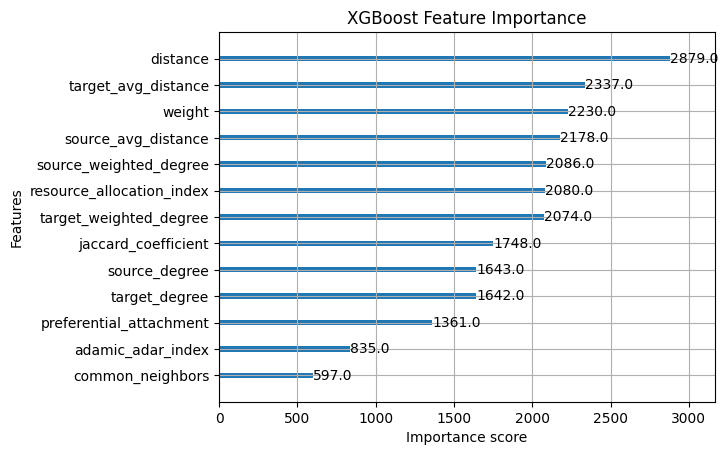

In [54]:
X = features_df
xgb_model, xgb_params = optimise(xgb, scoring, param_grid_xgb, X, 'Summer')

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': True}
Best F1 Score: 0.340923822085094
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     47271
           1       0.42      0.48      0.45      1030

    accuracy                           0.97     48301
   macro avg       0.71      0.73      0.72     48301
weighted avg       0.98      0.97      0.98     48301

Accuracy: 0.9750
F1 Score: 0.4492
Precision: 0.4232
Recall: 0.4786
Balanced Accuracy: 0.7322
AUC: 0.9522


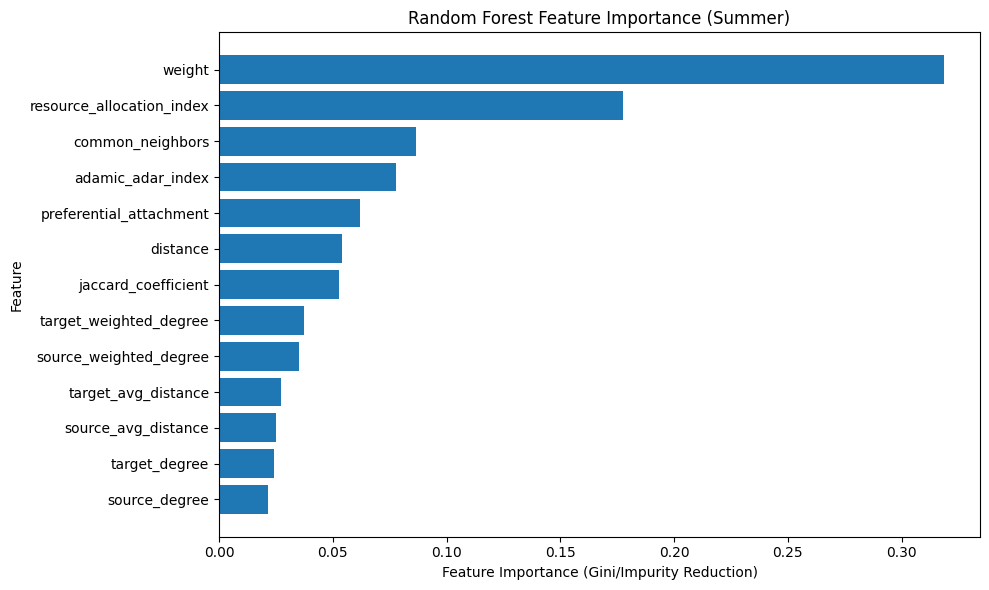

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.3}
Best F1 Score: 0.16360178318432114
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     47271
           1       0.48      0.10      0.17      1030

    accuracy                           0.98     48301
   macro avg       0.73      0.55      0.58     48301
weighted avg       0.97      0.98      0.97     48301

Accuracy: 0.9785
F1 Score: 0.1721
Precision: 0.4800
Recall: 0.1049
Balanced Accuracy: 0.5512
AUC: 0.8955


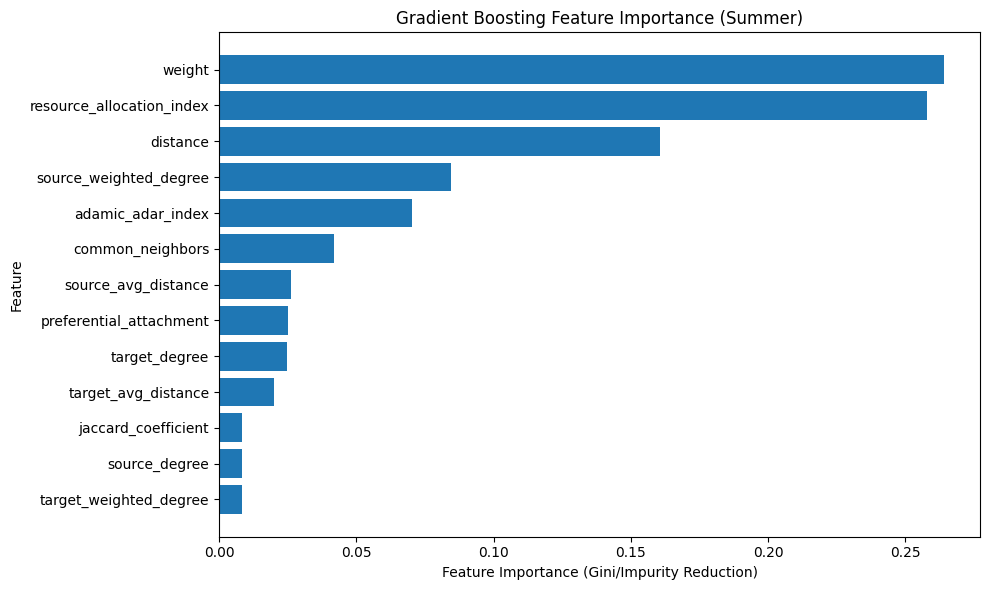

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 1}
Best F1 Score: 0.11409649901531287
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     47271
           1       0.12      0.92      0.21      1030

    accuracy                           0.85     48301
   macro avg       0.56      0.89      0.56     48301
weighted avg       0.98      0.85      0.90     48301

Accuracy: 0.8492
F1 Score: 0.2071
Precision: 0.1166
Recall: 0.9233
Balanced Accuracy: 0.8855
AUC: 0.9480


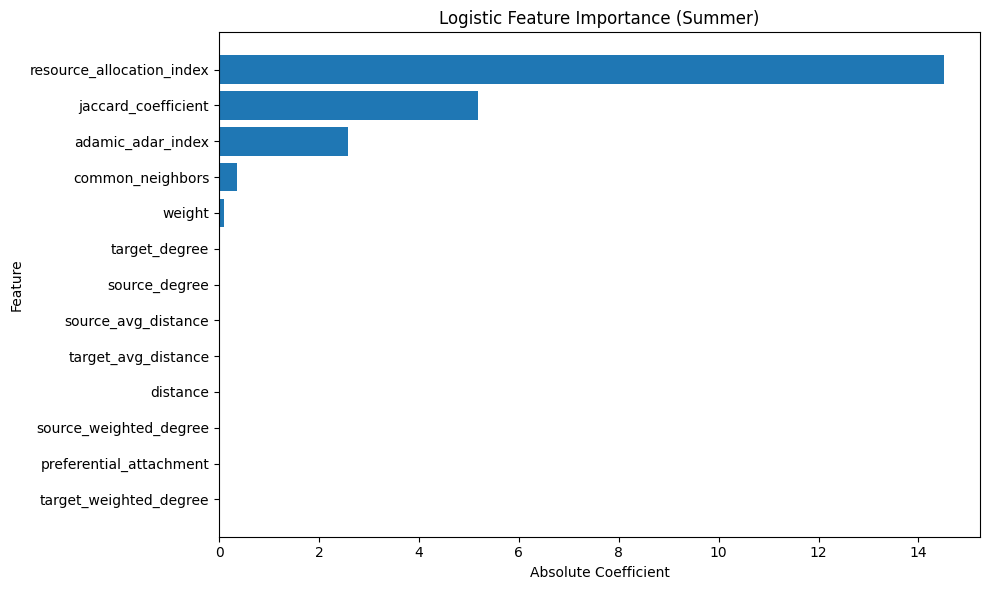

In [55]:
rf_model, rf_params = optimise(rf, scoring, param_grid_rf, X, 'Summer')
gbdt_model, gbdt_params = optimise(gbdt, scoring, param_grid_gbdt, X, 'Summer')
logres_model, logres_params = optimise(logres, scoring, param_grid_lr, X, 'Summer')

[0.3586527  0.54323393 0.24901009 0.29173297 0.47573462 0.23508084
 0.24935807 0.19622473 0.17330961 0.15998393 1.5197226  3.3531823
 0.57061464]


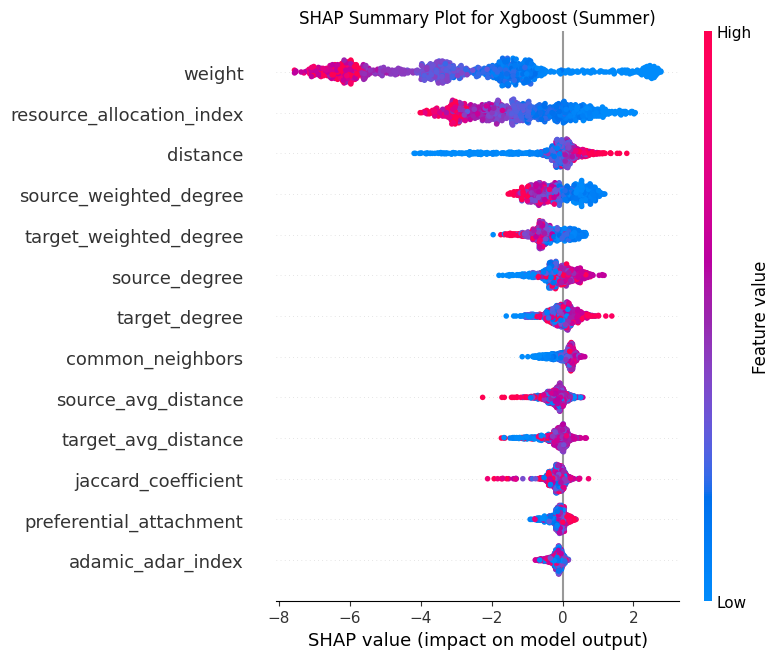

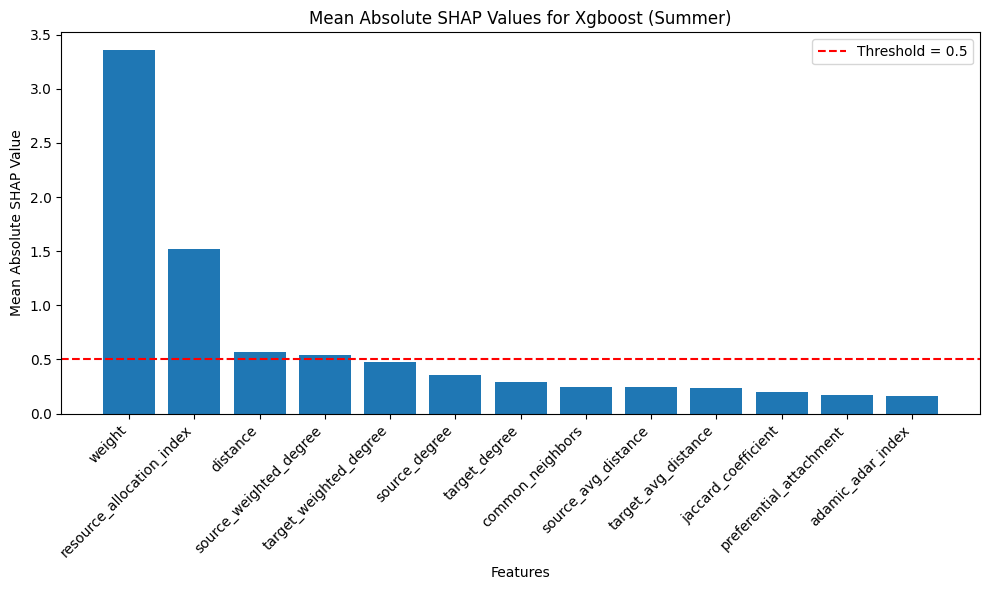

[0.02325229 0.01994905 0.0183348  0.02345081 0.02150674 0.01773022
 0.01962204 0.03766618 0.03783399 0.03918329 0.07736296 0.15898852
 0.02446808]


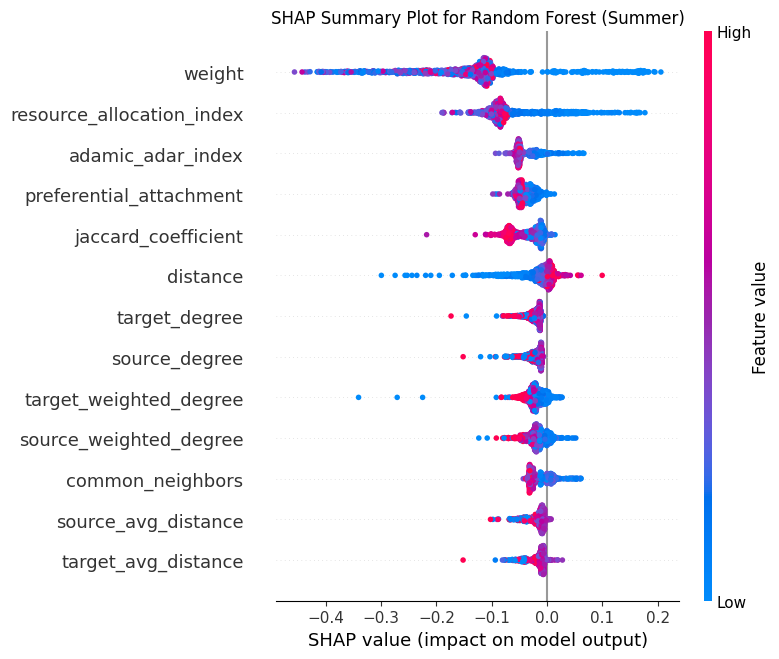

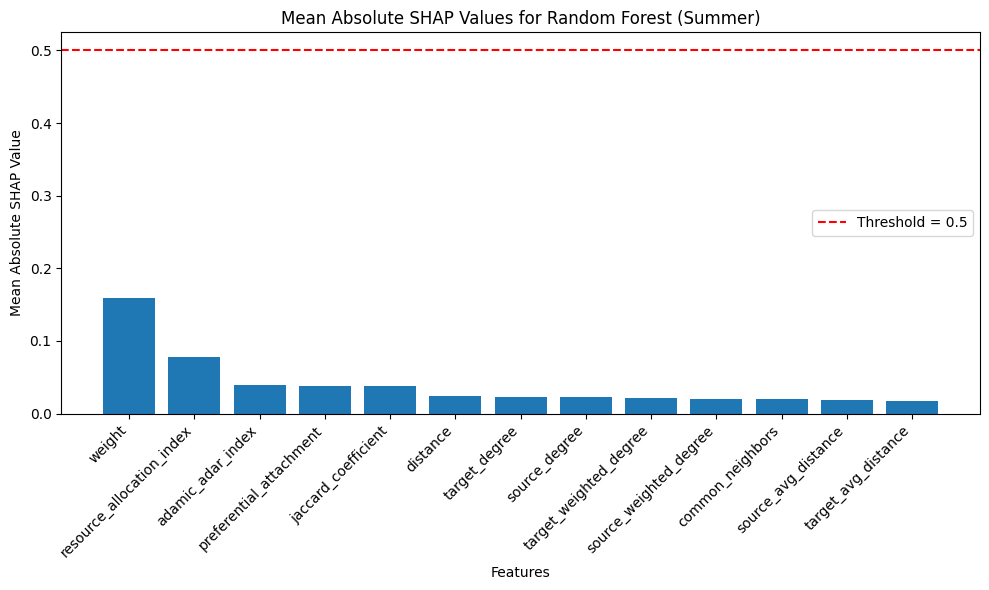

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [04:44<00:00,  3.52it/s]


[0.00971752 0.00272342 0.00787961 0.01278741 0.0012058  0.00619761
 0.17286476 0.02799248 0.00753436 0.26721015 0.17672277 0.11278666
 0.01399967]


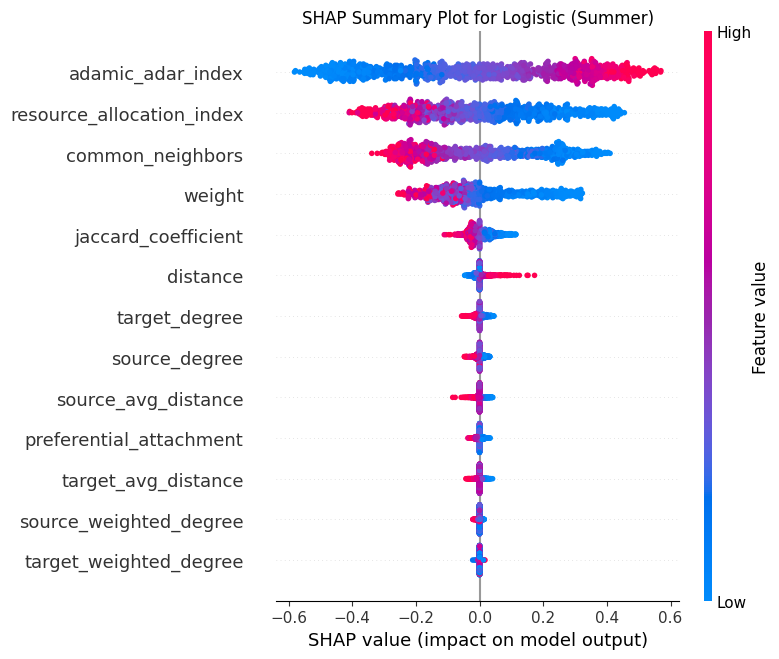

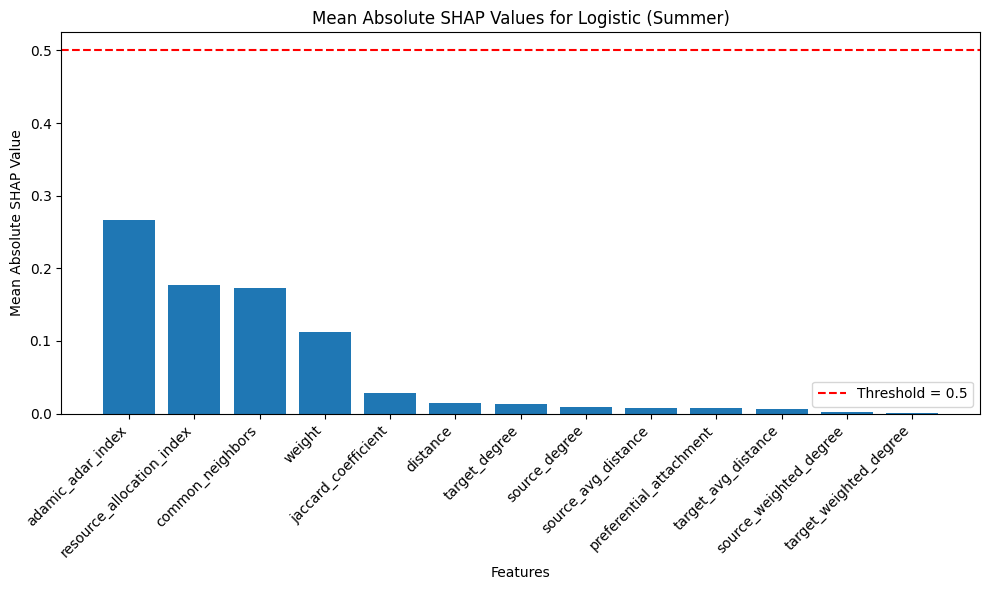

[6.90002976e+02 7.50079909e+15 5.93733230e+71 1.07760679e+03
 5.40375546e+09 4.52221523e+71 5.39653145e+02 9.68629661e+71
 2.49587154e+71 9.19037965e+70 3.11871237e+70 4.62554547e+70
 2.57985171e+71]


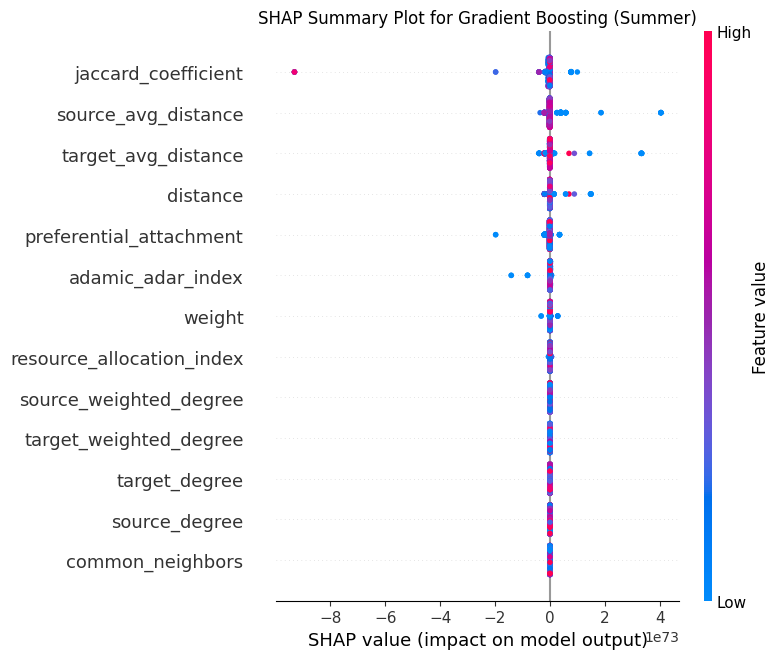

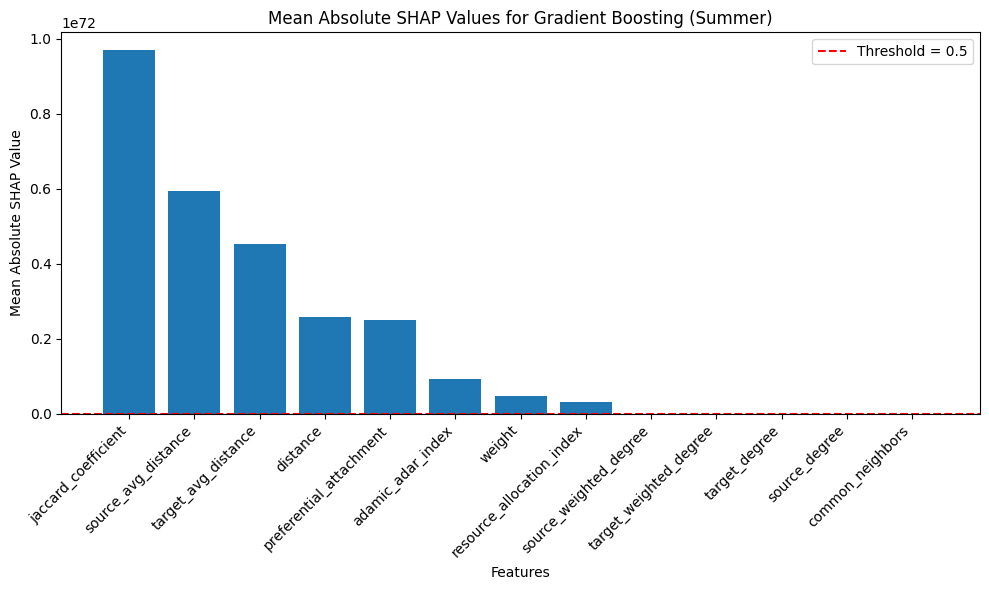

In [60]:
# Split the seasonal data by year
seasonal_splits = split_df_by_year(features_df)
years_sorted = sorted(seasonal_splits.keys())  # e.g., ['Winter 2019', ..., 'Winter 2023']
    
# Use all but the last year for training, and the last year for testing
train_years = years_sorted[:-2]
val_year = years_sorted[-2]
test_year = years_sorted[-1]
    
train_df = pd.concat([seasonal_splits[year] for year in train_years])
val_df = seasonal_splits[val_year]
shap_values_xgb = plot_shap_values(xgb_model, val_df[feature_names], feature_names, model_type='xgboost', season='Summer')
shap_values_rf = plot_shap_values(rf_model, val_df[feature_names], feature_names, model_type='random_forest', season='Summer')
shap_values_logres = plot_shap_values(logres_model, val_df[feature_names], feature_names, model_type='logistic', season='Summer')
shap_values_gbdt = plot_shap_values(gbdt_model, val_df[feature_names], feature_names, model_type='gradient_boosting', season='Summer')

In [62]:
from shap_select import shap_select	

selected_features_df_xgb = shap_select(xgb_model, val_df[feature_names], val_df['Removed'], task="binary", threshold=0.05)
print(selected_features_df_xgb)
selected_features_df = selected_features_df_xgb[selected_features_df_xgb['selected'] == 1]
sel_feat_list_xgb = selected_features_df['feature name'].tolist()
print(sel_feat_list_xgb)

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 14 out of 14 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 13 out of 13 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

                 feature name    t-value  stat.significance  coefficient  \
0                      weight  38.617311       0.000000e+00     1.279009   
1   resource_allocation_index  15.592426       8.196040e-55     0.629735   
2      source_weighted_degree   5.800547       6.609876e-09     0.433723   
3                    distance   4.898325       9.665708e-07     0.170140   
4               target_degree   4.859691       1.175694e-06     0.538411   
5      target_weighted_degree   4.601877       4.187001e-06     0.415743   
6     preferential_attachment   3.757528       1.716005e-04     1.081739   
7         source_avg_distance   2.326215       2.000710e-02     0.320336   
8         jaccard_coefficient   1.976513       4.809668e-02     0.329654   
9           adamic_adar_index   0.843651       3.988647e-01     0.350981   
10           common_neighbors   0.455770       6.485552e-01     0.107704   
11              source_degree  -0.791406       4.287073e-01    -0.098470   
12        ta

In [ ]:
mean_shap_values_rf = np.abs(shap_values_rf).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_shap_values_rf
}).sort_values(by='Importance', ascending=False)

rf_top_features = feature_importance['Feature'].head(10).tolist()
print("Top features from Random Forest based on SHAP values:")
print(rf_top_features)

Top features from Random Forest based on SHAP values:
['weight', 'resource_allocation_index', 'adamic_adar_index', 'preferential_attachment', 'jaccard_coefficient', 'distance', 'target_degree', 'source_degree', 'target_weighted_degree', 'source_weighted_degree']


In [66]:
mean_shap_values_gbdt = np.abs(shap_values_gbdt).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_shap_values_gbdt
}).sort_values(by='Importance', ascending=False)

gbdt_top_features = feature_importance['Feature'].head(10).tolist()
print("Top features from GBDT based on SHAP values:")
print(gbdt_top_features)

Top features from GBDT based on SHAP values:
['jaccard_coefficient', 'source_avg_distance', 'target_avg_distance', 'distance', 'preferential_attachment', 'adamic_adar_index', 'weight', 'resource_allocation_index', 'source_weighted_degree', 'target_weighted_degree']


In [67]:
mean_shap_values_logres = np.abs(shap_values_logres).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_shap_values_logres
}).sort_values(by='Importance', ascending=False)

logres_top_features = feature_importance['Feature'].head(10).tolist()
print("Top features from Logistic Regression based on SHAP values:")
print(logres_top_features)

Top features from Logistic Regression based on SHAP values:
['adamic_adar_index', 'resource_allocation_index', 'common_neighbors', 'weight', 'jaccard_coefficient', 'distance', 'target_degree', 'source_degree', 'source_avg_distance', 'preferential_attachment']


In [71]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, roc_auc_score

models = {
    'XGBoost': (XGBClassifier(random_state=42, **xgb_params), sel_feat_list_xgb),
    'RandomForest': (RandomForestClassifier(random_state=42, class_weight='balanced', **rf_params), rf_top_features),
    'GradientBoosting': (GradientBoostingClassifier(random_state=42, **gbdt_params), gbdt_top_features),
    'LogisticRegression': (LogisticRegression(random_state=42, class_weight='balanced', **logres_params), logres_top_features)
}

results = {}


# Use the same train/val/test split as before
seasonal_splits = split_df_by_year(features_df)
years_sorted = sorted(seasonal_splits.keys())
train_years = years_sorted[:-2]
val_year = years_sorted[-2]
test_year = years_sorted[-1]

train_df = pd.concat([seasonal_splits[year] for year in train_years])
val_df = seasonal_splits[val_year]
test_df = seasonal_splits[test_year]

for name, (model, selected_features) in models.items():
    X_train = train_df[selected_features]
    y_train = train_df['Removed'].astype(int)
    X_test = test_df[selected_features]
    y_test = test_df['Removed'].astype(int)
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    if hasattr(model, "predict_proba"):
        print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
    print("-" * 40)
    results[name] = model

Model: XGBoost
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     69804
           1       0.63      0.25      0.36      9160

    accuracy                           0.90     78964
   macro avg       0.77      0.62      0.65     78964
weighted avg       0.88      0.90      0.88     78964

Accuracy: 0.8963
F1 Score: 0.3632
Precision: 0.6313
Recall: 0.2549
Balanced Accuracy: 0.6177
AUC: 0.7522
----------------------------------------
Model: RandomForest
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     69804
           1       0.76      0.13      0.23      9160

    accuracy                           0.89     78964
   macro avg       0.83      0.56      0.59     78964
weighted avg       0.88      0.89      0.86     78964

Accuracy: 0.8947
F1 Score: 0.2287
Precision: 0.7624
Recall: 0.1345
Balanced Accuracy: 0.5645
AUC: 0.7126
--------------

In [74]:
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from bayes_opt import BayesianOptimization

def build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate):
    model = Sequential([
        LSTM(int(lstm1), activation='relu', return_sequences=True, input_shape=input_shape),
        LSTM(int(lstm2), activation='relu'),
        Dropout(0.3),
        Dense(int(dense), activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def optimise_lstm_bayesian(seasonal_data, season, init_points=5, n_iter=10, epochs=50, batch_size=32):
    seasonal_years = split_df_by_year(seasonal_data)
    years = sorted(seasonal_years.keys())
    
    # Split train/test
    train_df = pd.concat([seasonal_years[year] for year in years[:-2]])
    val_df = seasonal_years[years[-2]]
    test_df = seasonal_years[years[-1]]
    
    X_train = train_df[feature_names]
    y_train = train_df["Removed"].values
    X_val = val_df[feature_names]
    y_val = val_df["Removed"].values
    X_test = test_df[feature_names]
    y_test = test_df["Removed"].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_val_scaled = scaler.transform(X_val).reshape((X_val.shape[0], 1, X_val.shape[1]))
    X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    
    # Determine input shape
    num_features = X_train.shape[1]
    input_shape = (1, num_features)  # 1 timestep, N features

    # Objective function for Bayesian Optimization
    def train_eval(lstm1, lstm2, dense, learning_rate):
        model = build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate)
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                  validation_split=0.2, callbacks=[es], verbose=0)
        y_pred = model.predict(X_val_scaled)
        return f1_score(y_val, np.argmax(y_pred, axis=1))
    
    pbounds = {
        'lstm1': (32, 256),
        'lstm2': (16, 128),
        'dense': (16, 128),
        'learning_rate': (1e-4, 1e-2)
    }
    
    optimizer = BayesianOptimization(f=train_eval, pbounds=pbounds, random_state=42)
    optimizer.maximize(init_points=init_points, n_iter=n_iter)
    
    # Train best model
    best_params = optimizer.max['params']
    final_model = build_lstm_model(input_shape, **best_params)
    final_model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                    validation_split=0.2, verbose=0)
    
    y_pred_final = final_model.predict(X_val_scaled)
    y_pred_classes = np.argmax(y_pred_final, axis=1)

    # Report
    print("\nBest Hyperparameters:", best_params)
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred_classes))

    cm = confusion_matrix(y_val, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {season} 2023')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    metrics = {
        'f1': f1_score(y_val, y_pred_classes),
        'balanced_acc': balanced_accuracy_score(y_val, y_pred_classes),
        'auc': roc_auc_score(y_val, y_pred_final[:, 1])
    }
    
    return final_model, best_params, metrics

In [76]:
lsymbol_model, lstm_params, lstm_metrics = optimise_lstm_bayesian(features_df, 'Summer', init_points=10, n_iter=30, epochs=50, batch_size=32)

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1510/1510 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
| 1         | 0.0       | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1510/1510 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
| 2         | 0.0       | 33.47     | 0.001644  | 45.01     | 113.0     |


...

1510/1510 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
| 35        | 0.0       | 22.88     | 0.005208  | 127.7     | 122.7     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1510/1510 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
| 36        | 0.0       | 54.9      | 0.002252  | 181.4     | 33.93     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [112]:
seasonal_years = split_df_by_year(features_df)
years = sorted(seasonal_years.keys())
    
# Split train/test
train_df = pd.concat([seasonal_years[year] for year in years[:-2]])
val_df = seasonal_years[years[-2]]
test_df = seasonal_years[years[-1]]
    
X_train = train_df[feature_names]
y_train = train_df["Removed"].values
X_val = val_df[feature_names]
y_val = val_df["Removed"].values
X_test = test_df[feature_names]
y_test = test_df["Removed"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_scaled = scaler.transform(X_val).reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Determine input shape
num_features = X_train.shape[1]
input_shape = (1, num_features)

lstm_model = build_lstm_model(input_shape=input_shape, lstm1=248.3, lstm2=106.5, dense=23.29, learning_rate=0.009494)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lstm_model.fit(X_train_scaled, y_train_cat, epochs=10, batch_size=32,
            validation_split=0.2, callbacks=[es], verbose=0)

y_pred_final = lstm_model.predict(X_val_scaled)
y_pred_classes = np.argmax(y_pred_final, axis=1)

# Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_classes))

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1510/1510 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99     47271
        True       0.00      0.00      0.00      1030

    accuracy                           0.98     48301
   macro avg       0.49      0.50      0.49     48301
weighted avg       0.96      0.98      0.97     48301



c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [94]:
percentage_removed = features_df['Removed'].mean() * 100
print(f"Percentage of rows where 'Removed' is True: {percentage_removed:.2f}%")

Percentage of rows where 'Removed' is True: 1.42%


In [84]:
trajectories_dict = {}
for date in unique_dates:
    daily_df = features_df[features_df.index == date]
    G = daily_graphs[date]
    trajectories_dict[date] = []  # Initialize an empty list for each date
    for edge in G.edges():
        source, target = edge
        disrupted = daily_df[(daily_df['source'] == source) & (daily_df['destination'] == target)]['Removed'].values
        disrupted = disrupted[0] if len(disrupted) > 0 else False  # Handle cases where no match is found
        trajectories_dict[date].append((edge, disrupted))

In [86]:
from torch_geometric.data import Data
import torch

# Function to convert NetworkX graph and features to Data object
def graph_to_data(date, G, node_features, edge_features, trajectories):
    nodes = list(G.nodes())
    x = torch.tensor([list(node_features[node].values()) for node in nodes], dtype=torch.float)

    edges = list(G.edges())
    edge_index = torch.tensor([[nodes.index(u), nodes.index(v)] for u, v in edges], dtype=torch.long).t()
    edge_attr = torch.tensor([
        list(edge_features.get((u, v), {k: 0 for k in next(iter(edge_features.values())).keys()}).values())
        for u, v in edges
    ], dtype=torch.float)

    season = "Summer"
    year = date.year

    data_list = []
    for traj, label in trajectories:
        traj_indices = torch.tensor([nodes.index(node) for node in traj], dtype=torch.long)
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            trajectory=torch.tensor([nodes.index(node) for node in traj], dtype=torch.long),
            y=torch.tensor(label, dtype=torch.float)  # Not wrapped in [label]
        )
        # Add metadata for splitting
        data.season = season
        data.year = year
        data_list.append(data)

    return data_list

In [87]:
def get_trajectory_edge_attr(edge_index, edge_attr, trajectory):
    # trajectory: [T] (node indices)
    traj_edge_indices = torch.stack([trajectory[:-1], trajectory[1:]], dim=0)  # [2, T-1]
    # Find matching edges in edge_index
    traj_edge_attr = []
    for i in range(traj_edge_indices.shape[1]):
        src, dst = traj_edge_indices[0, i], traj_edge_indices[1, i]
        # Find edge (src, dst) or (dst, src) in edge_index
        mask = ((edge_index[0] == src) & (edge_index[1] == dst)) | ((edge_index[0] == dst) & (edge_index[1] == src))
        edge_idx = torch.where(mask)[0]
        if edge_idx.numel() > 0:
            traj_edge_attr.append(edge_attr[edge_idx[0]])
        else:
            # Handle missing edges (e.g., use zero vector or mean edge_attr)
            traj_edge_attr.append(torch.zeros_like(edge_attr[0]))
    return torch.stack(traj_edge_attr)  # [T-1, edge_feature_dim]

In [88]:
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool
import torch.nn.functional as F
from torch_geometric.data import Data


class GNN_LSTM(nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim, hidden_dim, output_dim):
        super().__init__()
        # GATConv with multi-head attention
        self.conv1 = GATConv(node_feature_dim, hidden_dim, heads=4, edge_dim=edge_feature_dim)
        self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, edge_dim=edge_feature_dim)
        self.skip1 = nn.Linear(node_feature_dim, hidden_dim * 4)  # Residual connection
        self.bn1 = nn.BatchNorm1d(hidden_dim * 4)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim // 2, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_dim + edge_feature_dim, output_dim)

    def forward(self, data):
        x, edge_index, edge_attr, trajectory = data.x, data.edge_index, data.edge_attr, data.trajectory
        
        # Normalize features
        x = (x - x.mean(dim=0)) / (x.std(dim=0) + 1e-8)
        edge_attr = (edge_attr - edge_attr.mean(dim=0)) / (edge_attr.std(dim=0) + 1e-8)

        # GATConv layers with residual connection
        x_in = x
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x + self.skip1(x_in))
        x = torch.relu(x)
        x = self.bn2(self.conv2(x, edge_index, edge_attr))
        x = torch.relu(x)
        x = F.dropout(x, p=0.35, training=self.training)

        # Extract trajectory embeddings
        traj_embeddings = x[trajectory]  # [T, hidden_dim]

        # LSTM for sequential modeling
        lstm_out, _ = self.lstm(traj_embeddings.unsqueeze(0))  # [1, T, hidden_dim//2]
        # Edge classification (consecutive nodes in trajectory)
        edge_embeddings = torch.cat([lstm_out[:, :-1], lstm_out[:, 1:]], dim=-1)  # [1, T-1, hidden_dim]
        traj_edge_features = get_trajectory_edge_attr(edge_index, edge_attr, trajectory)  # [T-1, edge_feature_dim]
        edge_input = torch.cat([edge_embeddings.squeeze(0), traj_edge_features], dim=-1)  # [T-1, hidden_dim + edge_feature_dim]
        out = self.fc(edge_input)  # [T-1, output_dim]
        return out

In [89]:
from collections import defaultdict
from torch_geometric.loader import DataLoader
seasonal_dataset = defaultdict(list)  # {'Winter': [Data, Data, ...], ...}

for date in unique_dates:
    G = daily_graphs[date]
    node_features = daily_features[date]
    edge_features = daily_edge_features[date]
    trajectories = trajectories_dict[date]
    
    daily_data = graph_to_data(date, G, node_features, edge_features, trajectories)
    season = 'Summer'
    if season is None:
        print(date)
    for data in daily_data:
        seasonal_dataset[season].append(data)

# (Optional) Check size of each seasonal split
for season, data_list in seasonal_dataset.items():
    print(f"{season}: {len(data_list)} samples")

Summer: 362859 samples


In [90]:
def split_by_year(seasonal_data, test_year=2021):
    train_data = [d for d in seasonal_data if d.year != test_year]
    test_data = [d for d in seasonal_data if d.year == test_year]
    return train_data, test_data

In [95]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
season = 'Summer'  # Change to the desired season

print(f"Processing season: {season}")
X_train, X_test = split_by_year(seasonal_dataset[season], test_year=2021)
print(f"{season} — Test set size: {len(X_test)}")

# Initialize model, loss, and optimizer
node_feature_dim = 3
edge_feature_dim = 7
hidden_dim = 32
output_dim = 1
model = GNN_LSTM(node_feature_dim, edge_feature_dim, hidden_dim, output_dim)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([0.99 / 0.01]))
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
train_loader = DataLoader(X_train, batch_size=1, shuffle=False)
test_loader = DataLoader(X_test, batch_size=1, shuffle=False)

# Training loop
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)  # [T-1, output_dim]
        y = data.y  # [T-1]
        loss = criterion(out.squeeze(-1), y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# Evaluation loop
def test():
    model.eval()
    total_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data in test_loader:
            out = model(data)  # [T-1, output_dim]
            y = data.y  # [T-1]
            loss = criterion(out.squeeze(-1), y.float())
            total_loss += loss.item()

            preds = (torch.sigmoid(out.squeeze(-1)) >= 0.5).int().cpu().numpy()
            labels = y.int().cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    ba = balanced_accuracy_score(y_true, y_pred)
    avg_loss = total_loss / len(test_loader)
    return avg_loss, precision, recall, f1, ba

# Early stopping parameters
patience = 5
best_test_loss = np.inf
patience_counter = 0
best_model_path = f"best_gnn_lstm_model_{season}.pth"

epochs = 10
for epoch in range(epochs):
    train_loss = train()
    test_loss, p, r, f1, ba = test()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, F1: {f1:.4f}")

    scheduler.step(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            print(f"Best Test Loss: {best_test_loss:.4f}, Precision: {p:.4f}, Recall: {r:.4f}, F1: {f1:.4f}, Balanced Accuracy: {ba:.4f}")
            break

# Load the best model
model.load_state_dict(torch.load(best_model_path))
model_DGNN = model
print("Loaded best model with test loss: {:.4f}".format(best_test_loss))

Processing season: Summer
Summer — Test set size: 22075


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Train Loss: 1.0227, Test Loss: 188.2005, F1: 0.4620
Epoch 2, Train Loss: 0.9579, Test Loss: 209.6635, F1: 0.4648
Epoch 3, Train Loss: 0.9557, Test Loss: 217.2227, F1: 0.4663
Epoch 4, Train Loss: 0.9561, Test Loss: 218.9633, F1: 0.4662
Epoch 5, Train Loss: 0.9511, Test Loss: 221.7528, F1: 0.4667
Epoch 6, Train Loss: 0.9516, Test Loss: 215.8225, F1: 0.4715
Early stopping triggered after 6 epochs.
Best Test Loss: 188.2005, Precision: 0.6191, Recall: 0.3808, F1: 0.4715, Balanced Accuracy: 0.6073
Loaded best model with test loss: 188.2005


In [96]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score
from tqdm import tqdm

def bootstrap_metrics(model, test_data, n_bootstrap=100, seed=42):
    np.random.seed(seed)
    metrics = {'precision': [], 'recall': [], 'f1': [], 'ba': [], 'auc': []}
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    test_data = list(test_loader)  # Convert DataLoader to list for indexing
    print(len(test_data))
    for _ in tqdm(range(n_bootstrap)):
        indices = np.random.choice(len(test_data), len(test_data), replace=True)
        y_true, y_pred, y_prob = [], [], []
        for idx in indices:
            data = test_data[idx]
            model.eval()
            with torch.no_grad():
                out = model(data)
                prob = torch.sigmoid(out.squeeze(-1)).cpu().numpy()
                pred = (prob >= 0.5).astype(int)
                label = data.y.int().cpu().numpy()
                y_true.extend(label)
                y_pred.extend(pred)
                y_prob.extend(prob)
        # Handle cases where only one class is present in y_true
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = np.nan
        metrics['precision'].append(precision_score(y_true, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_true, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_true, y_pred, zero_division=0))
        metrics['ba'].append(balanced_accuracy_score(y_true, y_pred))
        metrics['auc'].append(auc)
    return metrics

print(f"Bootstrapping metrics for {season}...")
# Get the test set for this season
_, test_data = split_by_year(seasonal_dataset[season], test_year=2021)
DGNN_metrics = bootstrap_metrics(model_DGNN, test_data, n_bootstrap=100)

print(f"{season} - Precision: {np.mean(DGNN_metrics['precision']):.3f} ± {np.std(DGNN_metrics['precision']):.3f}")
print(f"{season} - Recall: {np.mean(DGNN_metrics['recall']):.3f} ± {np.std(DGNN_metrics['recall']):.3f}")
print(f"{season} - F1: {np.mean(DGNN_metrics['f1']):.3f} ± {np.std(DGNN_metrics['f1']):.3f}")
print(f"{season} - Balanced Accuracy: {np.mean(DGNN_metrics['ba']):.3f} ± {np.std(DGNN_metrics['ba']):.3f}")
print(f"{season} - AUC: {np.nanmean(DGNN_metrics['auc']):.3f} ± {np.nanstd(DGNN_metrics['auc']):.3f}")

Bootstrapping metrics for Summer...
22075


100%|██████████| 100/100 [4:56:15<00:00, 177.76s/it] 


Summer - Precision: 0.609 ± 0.006
Summer - Recall: 0.372 ± 0.004
Summer - F1: 0.462 ± 0.004
Summer - Balanced Accuracy: 0.601 ± 0.002
Summer - AUC: 0.622 ± 0.003


In [114]:
dgnn_df = pd.DataFrame({
    'precision': DGNN_metrics['precision'],
    'recall': DGNN_metrics['recall'],
    'f1': DGNN_metrics['f1'],
    'balanced_acc': DGNN_metrics['ba'],
    'auc': DGNN_metrics['auc']})

In [97]:
def plot_scores(scores_by_model, season='Winter', scores='F1'):
    df = pd.DataFrame([
        {'Model': model, 'Score': score}
        for model, scores in scores_by_model.items()
        for score in scores
    ])
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')
    plt.title(f"{scores} Score Distribution by Model ({season})")
    plt.grid(True)
    plt.show()

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\utils\optimize.py:246: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being s

2468/2468 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
  34/2468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step  

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


2468/2468 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
  35/2468 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step  

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


2468/2468 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Paired t-tests on F1 for Summer ---
xgb vs rf: t = 554.898, p = 0.0000
xgb vs gbdt: t = 467.855, p = 0.0000
xgb vs logres: t = 603.166, p = 0.0000
xgb vs lstm: t = 603.166, p = 0.0000
xgb vs gnn_lstm: t = -136.153, p = 1.0000
rf vs gbdt: t = -91.133, p = 1.0000
rf vs logres: t = 85.303, p = 0.0000
rf vs lstm: t = 85.303, p = 0.0000
rf vs gnn_lstm: t = -1005.176, p = 1.0000
gbdt vs logres: t = 154.351, p = 0.0000
gbdt vs lstm: t = 154.351, p = 0.0000
gbdt vs gnn_lstm: t = -813.297, p = 1.0000
logres vs lstm: t = nan, p = nan
logres vs gnn_lstm: t = -1131.600, p = 1.0000
lstm vs gnn_lstm: t = -1131.600, p = 1.0000

--- Bootstrap Confidence Intervals (Summer) ---

xgb:
f1: 0.363 (0.353–0.373)
precision: 0.630 (0.614–0.646)
recall: 0.255 (0.247–0.264)
balanced_acc: 0.618 (0.613–0.622)
auc: 0.752 (0.747–0.759)

rf:
f1: 0.015 (0.012–0.019)
precision: 0.845 (0.778–0.910)
recall: 0.008 (0.006–0.009)
balanced_acc: 0.504 (0.503–0.505)
auc: 0.720 (0.714–0.727)

gbdt:
f1: 0.047 (0.040–0.052)


C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


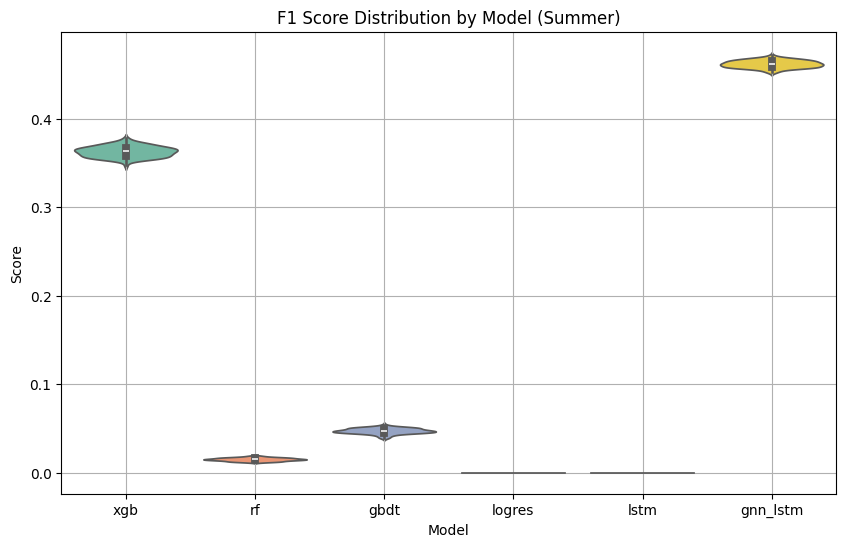

C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


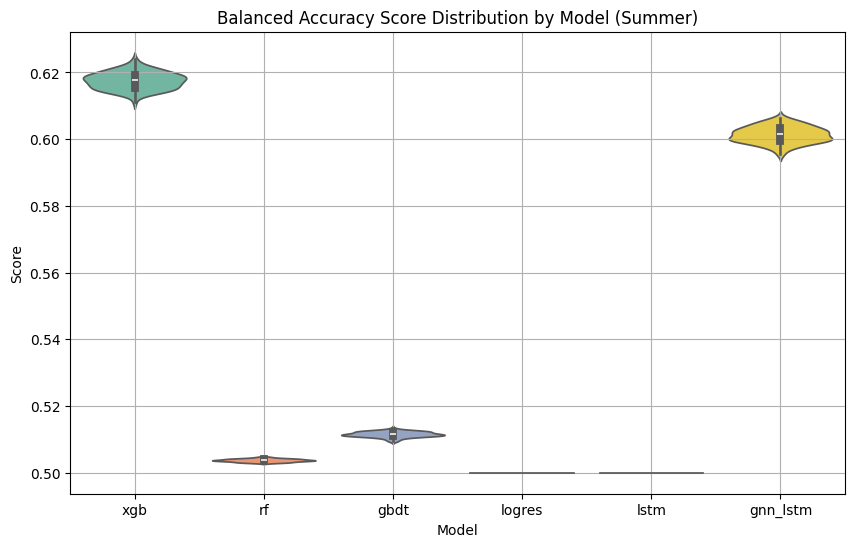

C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


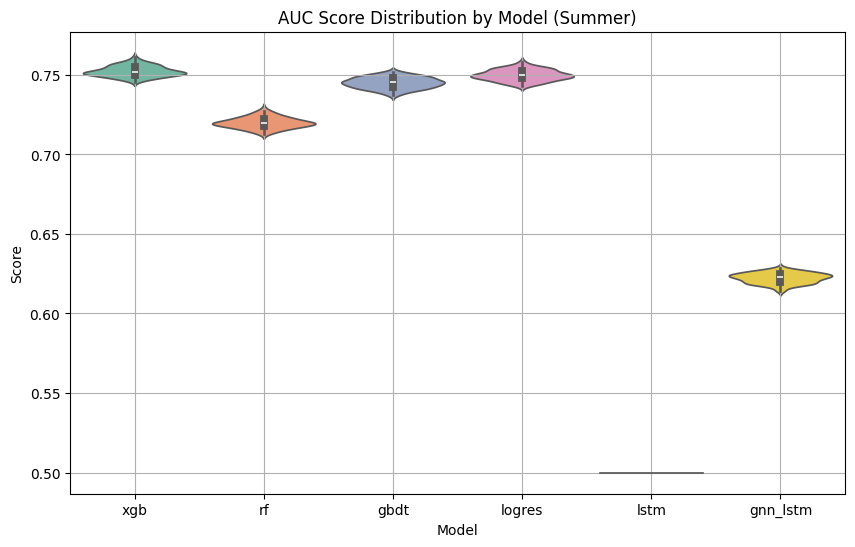

In [115]:
from scipy.stats import ttest_ind

def bootstrap_metrics_scores(model, X, y, is_lstm=False, n_bootstraps=100, seed=42):
    rng = np.random.RandomState(seed)
    scores = {
        'f1': [], 'precision': [], 'recall': [], 'balanced_acc': [], 'auc': []
    }
    
    for _ in range(n_bootstraps):
        indices = rng.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices].astype(int)

        if is_lstm:
            scaler = StandardScaler()
            X_sample_reset = X_sample.reset_index(drop=True)  # Ensure alignment
            y_sample = y_sample.reset_index(drop=True)        # Align labels
    
            X_scaled = scaler.fit_transform(X_sample_reset)
            X_np = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
    
            y_pred = model.predict(X_np)
            y_pred_prob = np.argmax(y_pred, axis=1)
        else:
            y_pred_prob = model.predict_proba(X_sample)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_sample)

        y_pred = (y_pred_prob >= 0.5).astype(int)

        scores['f1'].append(f1_score(y_sample, y_pred))
        scores['precision'].append(precision_score(y_sample, y_pred))
        scores['recall'].append(recall_score(y_sample, y_pred))
        scores['balanced_acc'].append(balanced_accuracy_score(y_sample, y_pred))
        try:
            scores['auc'].append(roc_auc_score(y_sample, y_pred_prob))
        except:
            scores['auc'].append(np.nan)

    return scores

def get_confidence_interval(data, ci=95):
    lower = np.percentile(data, (100 - ci) / 2)
    upper = np.percentile(data, 100 - (100 - ci) / 2)
    return lower, upper

def compare_models(models, X_test_dict, y_test, season, gnn_results=None):
    all_metrics = {}

    for name, model in models.items():
        is_lstm = (name == 'lstm')
        scores = bootstrap_metrics_scores(model, X_test_dict[name], y_test, is_lstm=is_lstm)
        all_metrics[name] = scores

    # Include GNN_LSTM scores from gnn_results if provided
    if gnn_results is not None:
        all_metrics['gnn_lstm'] = gnn_results

    model_names = list(all_metrics.keys())
    
    print(f"\n--- Paired t-tests on F1 for {season} ---")
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_ind(all_metrics[m1]['f1'], all_metrics[m2]['f1'], alternative='greater')
            print(f"{m1} vs {m2}: t = {t_stat:.3f}, p = {p_val:.4f}")
    
    # Print confidence intervals
    print(f"\n--- Bootstrap Confidence Intervals ({season}) ---")
    for name, scores in all_metrics.items():
        print(f"\n{name}:")
        for metric in scores:
            mean = np.mean(scores[metric])
            low, high = get_confidence_interval(scores[metric])
            print(f"{metric}: {mean:.3f} ({low:.3f}–{high:.3f})")

    return {k: v['f1'] for k, v in all_metrics.items()}, {k: v['balanced_acc'] for k, v in all_metrics.items()}, {k: v['auc'] for k, v in all_metrics.items()}  # Return only F1 scores


# Get the seasonal data

seasonal_years = split_df_by_year(features_df)
years = sorted(seasonal_years.keys())
    
# Split train/test
train_data = pd.concat([seasonal_years[year] for year in years[:-2]])
val_df = seasonal_years[years[-2]]
test_data = seasonal_years[years[-1]]


y_train = train_data['Removed'].astype(int)
y_test = test_data['Removed'].astype(int)

selected_features = {
    'xgb': sel_feat_list_xgb,
    'rf': rf_top_features,
    'gbdt': gbdt_top_features,
    'logres': logres_top_features
}

models = {}
X_test_dict = {}

for model_name in ['xgb', 'rf', 'gbdt', 'logres']:
    X_train = train_data[selected_features[model_name]]
    X_test = test_data[selected_features[model_name]]
    
    if model_name == 'xgb':
        model = XGBClassifier(random_state=42, **xgb_params)
    elif model_name == 'rf':
        model = RandomForestClassifier(random_state=42, **rf_params)
    elif model_name == 'gbdt':
        model = GradientBoostingClassifier(random_state=42, **gbdt_params)
    elif model_name == 'logres':
        model = LogisticRegression(random_state=42, **logres_params)
    
    model.fit(X_train, y_train)
    models[model_name] = model
    X_test_dict[model_name] = X_test

# Add LSTM
X_test_lstm = test_data[feature_names]
X_test_dict['lstm'] = X_test_lstm
models['lstm'] = lstm_model

# Compare models
f1_scores, ba_scores, auc_scores = compare_models(models, X_test_dict, y_test, season, gnn_results=dgnn_df)
plot_scores(f1_scores, season=season, scores='F1')
plot_scores(ba_scores, season=season, scores='Balanced Accuracy')
plot_scores(auc_scores, season=season, scores='AUC')
summer_f1_scores = {k: np.mean(v) for k, v in f1_scores.items()}
summer_ba_scores = {k: np.mean(v) for k, v in ba_scores.items()}
summer_auc_scores = {k: np.mean(v) for k, v in auc_scores.items()}

In [119]:
print(f1_scores['gnn_lstm'])

0     0.455887
1     0.457006
2     0.462702
3     0.461444
4     0.453765
        ...   
95    0.465422
96    0.468157
97    0.458182
98    0.461997
99    0.462950
Name: f1, Length: 100, dtype: float64


C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


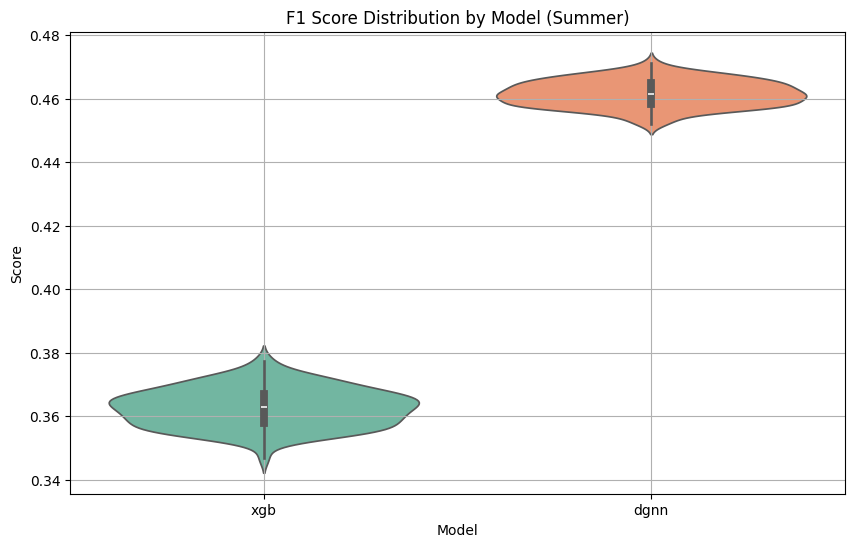

C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


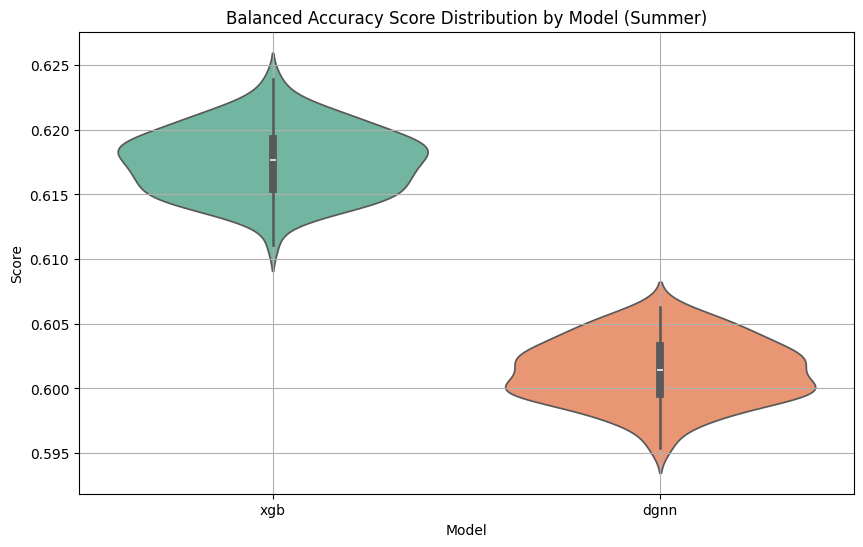

C:\Users\brake\AppData\Local\Temp\ipykernel_53128\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


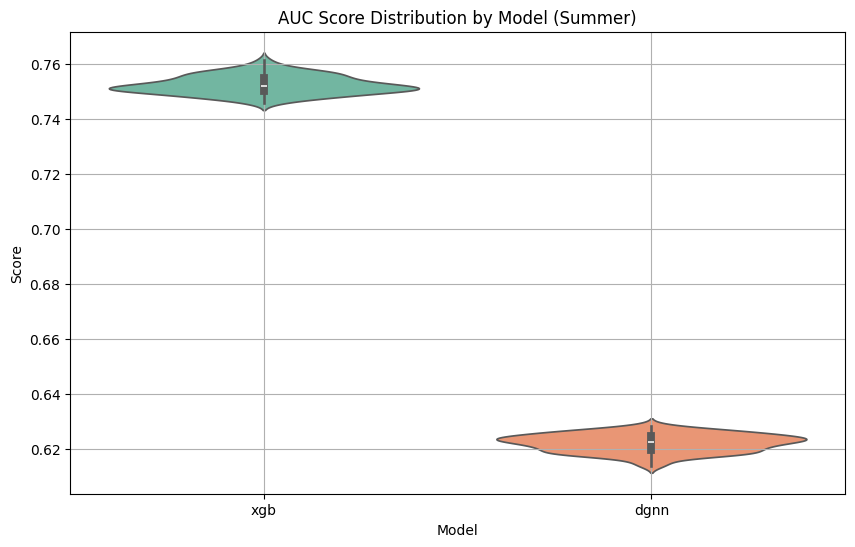

In [121]:
external_f1 = {'xgb': f1_scores['xgb'], 'dgnn': f1_scores['gnn_lstm']}
external_ba = {'xgb': ba_scores['xgb'], 'dgnn': ba_scores['gnn_lstm']}
external_auc = {'xgb': auc_scores['xgb'], 'dgnn': auc_scores['gnn_lstm']}
plot_scores(external_f1, season=season, scores='F1')
plot_scores(external_ba, season=season, scores='Balanced Accuracy')
plot_scores(external_auc, season=season, scores='AUC')